In [8]:
import pandas as pd

# Define column names based on UCI WDBC dataset description
# ID, Diagnosis, and 30 features (mean, standard error, worst for 10 characteristics)
features_base = [
    'radius',
    'texture',
    'perimeter',
    'area',
    'smoothness',
    'compactness',
    'concavity',
    'concave_points',
    'symmetry',
    'fractal_dimension'
]

column_names = ['ID', 'diagnosis']
for prefix in ['mean', 'se', 'worst']:
    for feature in features_base:
        column_names.append(f'{prefix}_{feature}')

# Load the dataset
df = pd.read_csv('/content/wdbc.data', header=None, names=column_names)

# Display the first 5 rows and a summary of the DataFrame
display(df.head())
print(df.info())

,ID,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   mean_radius              569 non-null    float64
 3   mean_texture             569 non-null    float64
 4   mean_perimeter           569 non-null    float64
 5   mean_area                569 non-null    float64
 6   mean_smoothness          569 non-null    float64
 7   mean_compactness         569 non-null    float64
 8   mean_concavity           569 non-null    float64
 9   mean_concave_points      569 non-null    float64
 10  mean_symmetry            569 non-null    float64
 11  mean_fractal_dimension   569 non-null    float64
 12  se_radius                569 non-null    float64
 13  se_texture               569 non-null    float64
 14  se_perimeter             5

Now, let's perform the initial data validation checks:

1.  **Confirm 569 rows and 32 columns:** The `df.info()` output already confirms this. We expect 569 instances and 32 columns (ID, diagnosis, and 30 features).
2.  **Verify label mapping (M/B):** Check the unique values and distribution of the 'diagnosis' column.
3.  **Check for missing values:** Confirm there are no nulls, as stated in the problem description.
4.  **Check for duplicates:** Identify any duplicate rows.

In [9]:
# 2. Verify label mapping (M/B) and class distribution
print("\nDiagnosis label distribution:")
display(df['diagnosis'].value_counts())
display(df['diagnosis'].value_counts(normalize=True) * 100)

# 3. Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# 4. Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Diagnosis label distribution:


,count
diagnosis,
B,357
M,212


,proportion
diagnosis,
B,62.741652
M,37.258348



Missing values per column:


,0
ID,0
diagnosis,0
mean_radius,0
mean_texture,0
mean_perimeter,0
mean_area,0
mean_smoothness,0
mean_compactness,0
mean_concavity,0
mean_concave_points,0



Number of duplicate rows: 0


### Investigating Outliers with Box Plots

Outliers can significantly impact model performance. We will use box plots to visualize the distribution of each numerical feature and identify any data points that lie far from the bulk of the data. Values beyond the whiskers of the box plot are typically considered potential outliers.

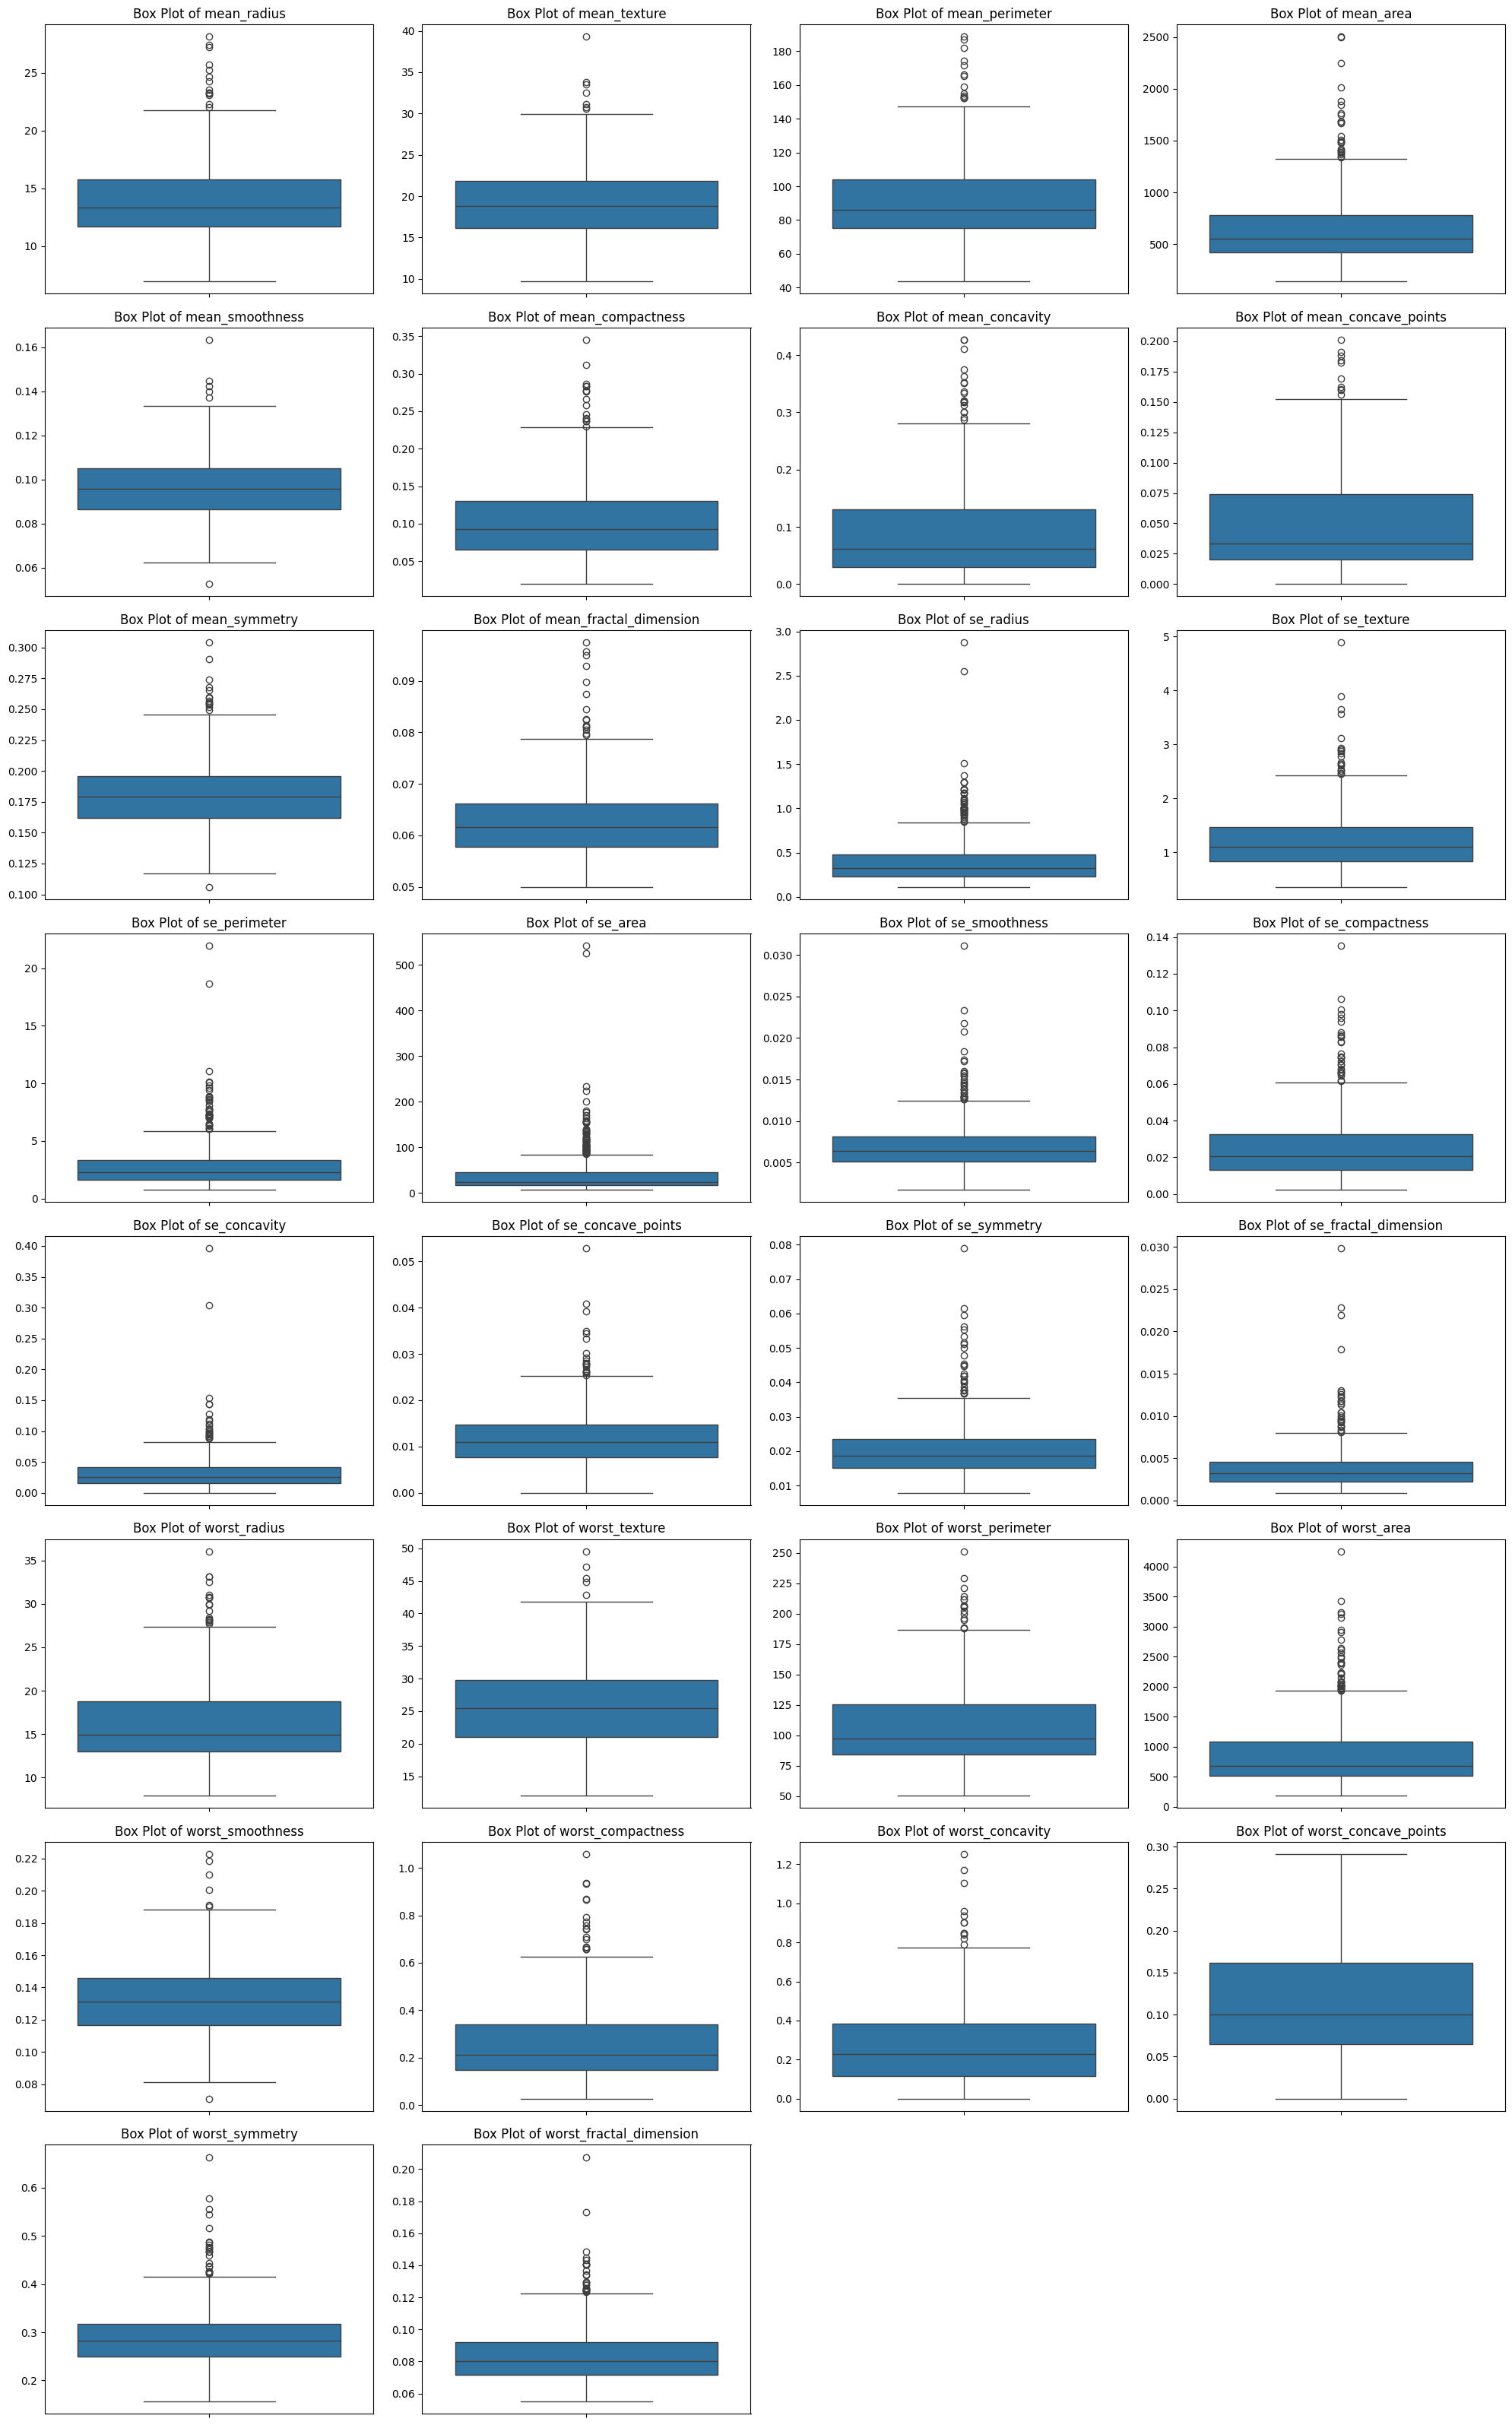

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'ID' and 'diagnosis' columns for outlier detection on numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('ID')

# Determine the number of rows and columns for the subplots
num_features = len(numerical_cols)
num_cols = 4  # Number of columns for the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter

plt.tight_layout()
plt.show()

### Handling Outliers with Capping

To address the outliers identified in the box plots, we will use **percentile-based capping**. This technique limits extreme values by replacing any data point below the 1st percentile with the value at the 1st percentile, and any data point above the 99th percentile with the value at the 99th percentile. This approach helps to normalize the data distribution and reduce the influence of outliers on subsequent analyses and model training, while preserving the overall dataset size.

In [11]:
import numpy as np

# Exclude 'ID' and 'diagnosis' columns, as 'diagnosis' is categorical
numerical_cols = df.select_dtypes(include=np.number).columns.drop('ID')

for col in numerical_cols:
    # Calculate 1st and 99th percentiles
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)

    # Apply capping
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers handled by capping values at the 1st and 99th percentiles for all numerical features.")

# Display descriptive statistics after capping to see the effect on min/max values
display(df[numerical_cols].describe())

Outliers handled by capping values at the 1st and 99th percentiles for all numerical features.


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.113362,19.263470,91.889771,651.295227,0.096305,0.104193,0.088369,0.048689,0.181089,0.062729,...,16.252581,25.659471,107.132718,876.073835,0.132252,0.252982,0.270579,0.114480,0.289473,0.083769
std,3.439789,4.192831,23.752853,334.962197,0.013554,0.051881,0.078109,0.038033,0.026530,0.006721,...,4.754601,5.996528,33.020473,548.004368,0.022165,0.151712,0.202652,0.065417,0.058421,0.017097
min,8.458360,10.930400,53.827600,215.664000,0.068654,0.033351,0.000000,0.000000,0.129508,0.051504,...,9.207600,15.200800,58.270400,256.192000,0.087910,0.050094,0.000000,0.000000,0.176028,0.058580
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,24.371600,30.652000,165.724000,1786.600000,0.132888,0.277192,0.351688,0.164208,0.259564,0.085438,...,30.762800,41.802400,208.304000,2918.160000,0.188908,0.778644,0.902380,0.269216,0.486908,0.140628


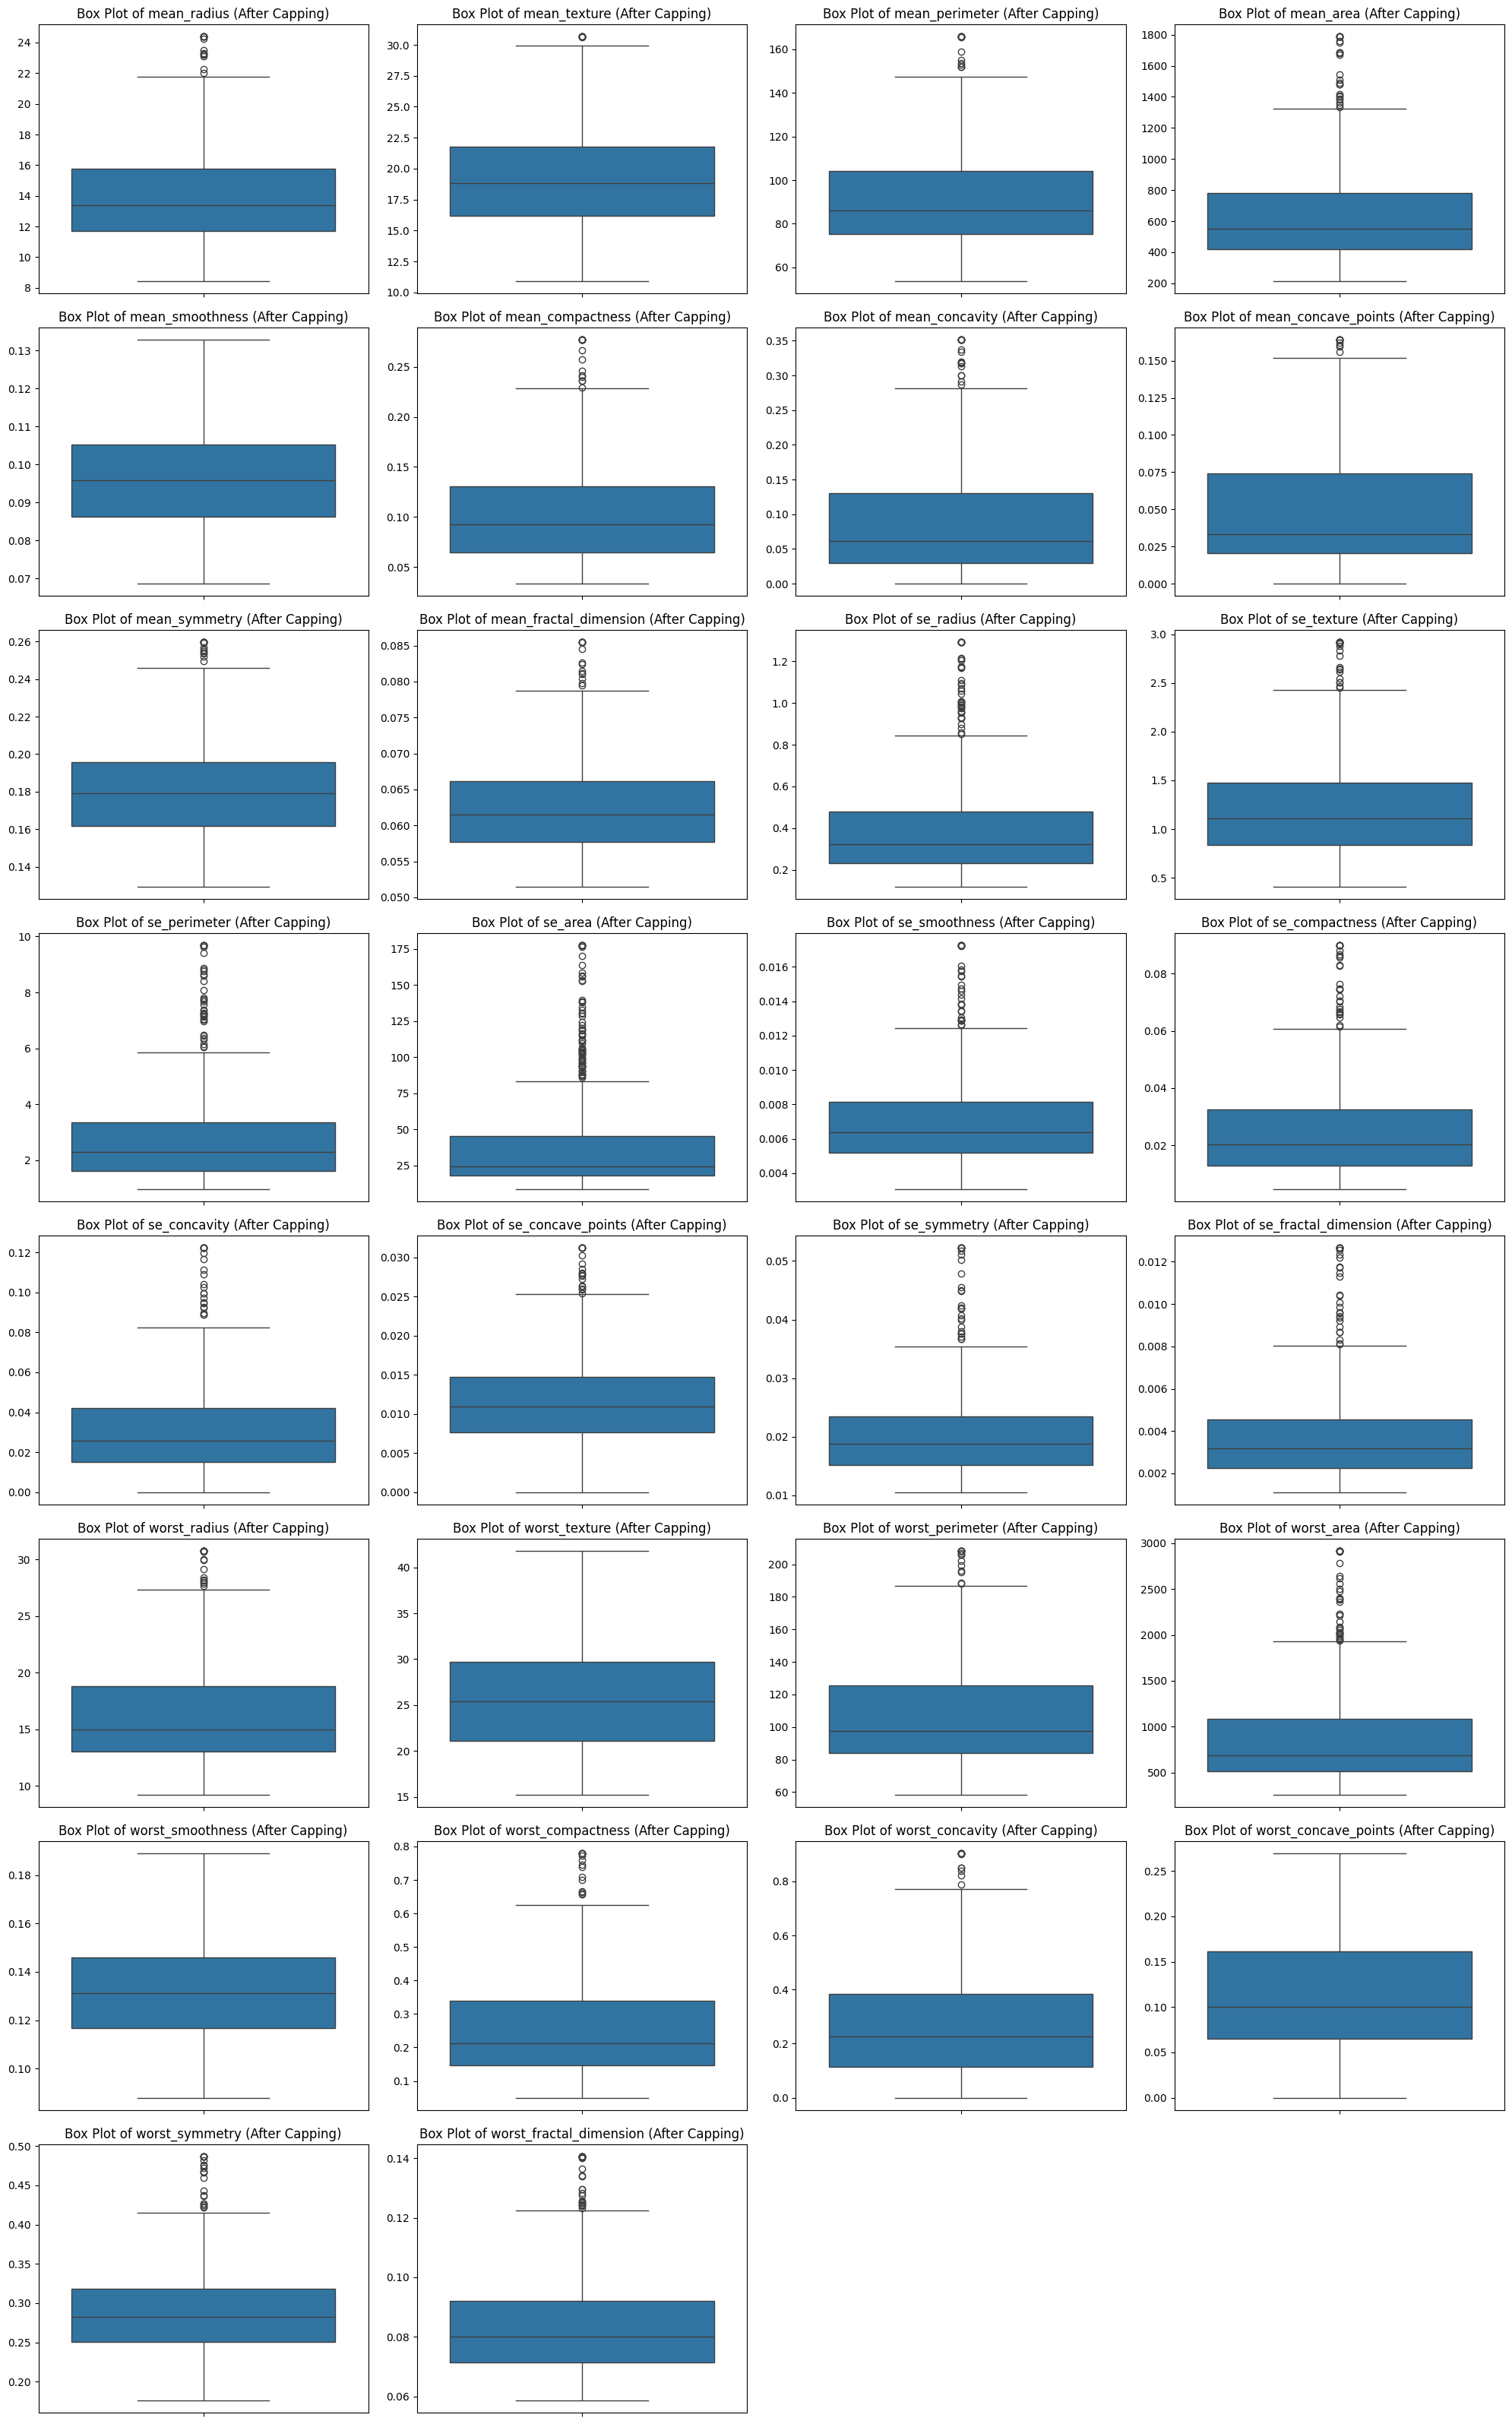

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'ID' and 'diagnosis' columns for outlier detection on numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('ID')

# Determine the number of rows and columns for the subplots
num_features = len(numerical_cols)
num_cols = 4  # Number of columns for the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel('') # Remove y-axis label to avoid clutter

plt.tight_layout()
plt.show()

## Phase 2: Decision-Oriented EDA

### 2.1 Target Variable Encoding

As part of preparing for modeling and for better analysis during EDA (e.g., correlation matrices), we will encode the `diagnosis` column. Following the problem statement, 'M' (Malignant) will be encoded as 1, and 'B' (Benign) as 0.

In [13]:
# Encode 'diagnosis' column (M=1, B=0)
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Diagnosis column encoded successfully. Displaying first 5 rows with new column:")
display(df[['diagnosis', 'diagnosis_encoded']].head())

Diagnosis column encoded successfully. Displaying first 5 rows with new column:


,diagnosis,diagnosis_encoded
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


### 2.2 Class Balance Check

While already performed in Phase 1, we will re-examine the class balance of our target variable (`diagnosis_encoded`) to ensure our model training will account for it, especially since the problem statement emphasizes stratified splitting.


Encoded Diagnosis label distribution:


,count
diagnosis_encoded,
0,357
1,212


,proportion
diagnosis_encoded,
0,62.741652
1,37.258348


/tmp/ipykernel_6699/2166207264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis_encoded', data=df, palette='viridis')


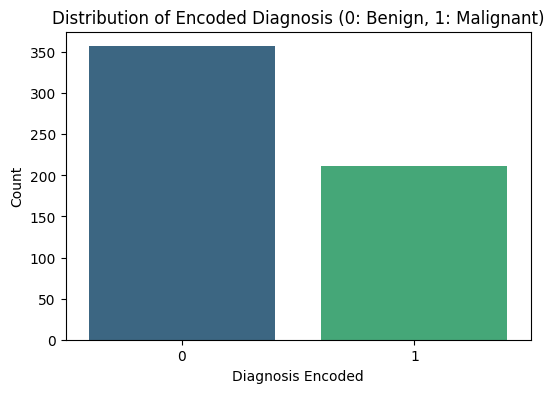

In [14]:
print("\nEncoded Diagnosis label distribution:")
display(df['diagnosis_encoded'].value_counts())
display(df['diagnosis_encoded'].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis_encoded', data=df, palette='viridis')
plt.title('Distribution of Encoded Diagnosis (0: Benign, 1: Malignant)')
plt.xlabel('Diagnosis Encoded')
plt.ylabel('Count')
plt.show()

### 2.3 Feature Distributions

We will visualize the distribution of each numerical feature using histograms. This helps identify skewness, multi-modality, and general data spread. We'll also separate them by diagnosis to get a first intuition of how features differ between benign and malignant cases.

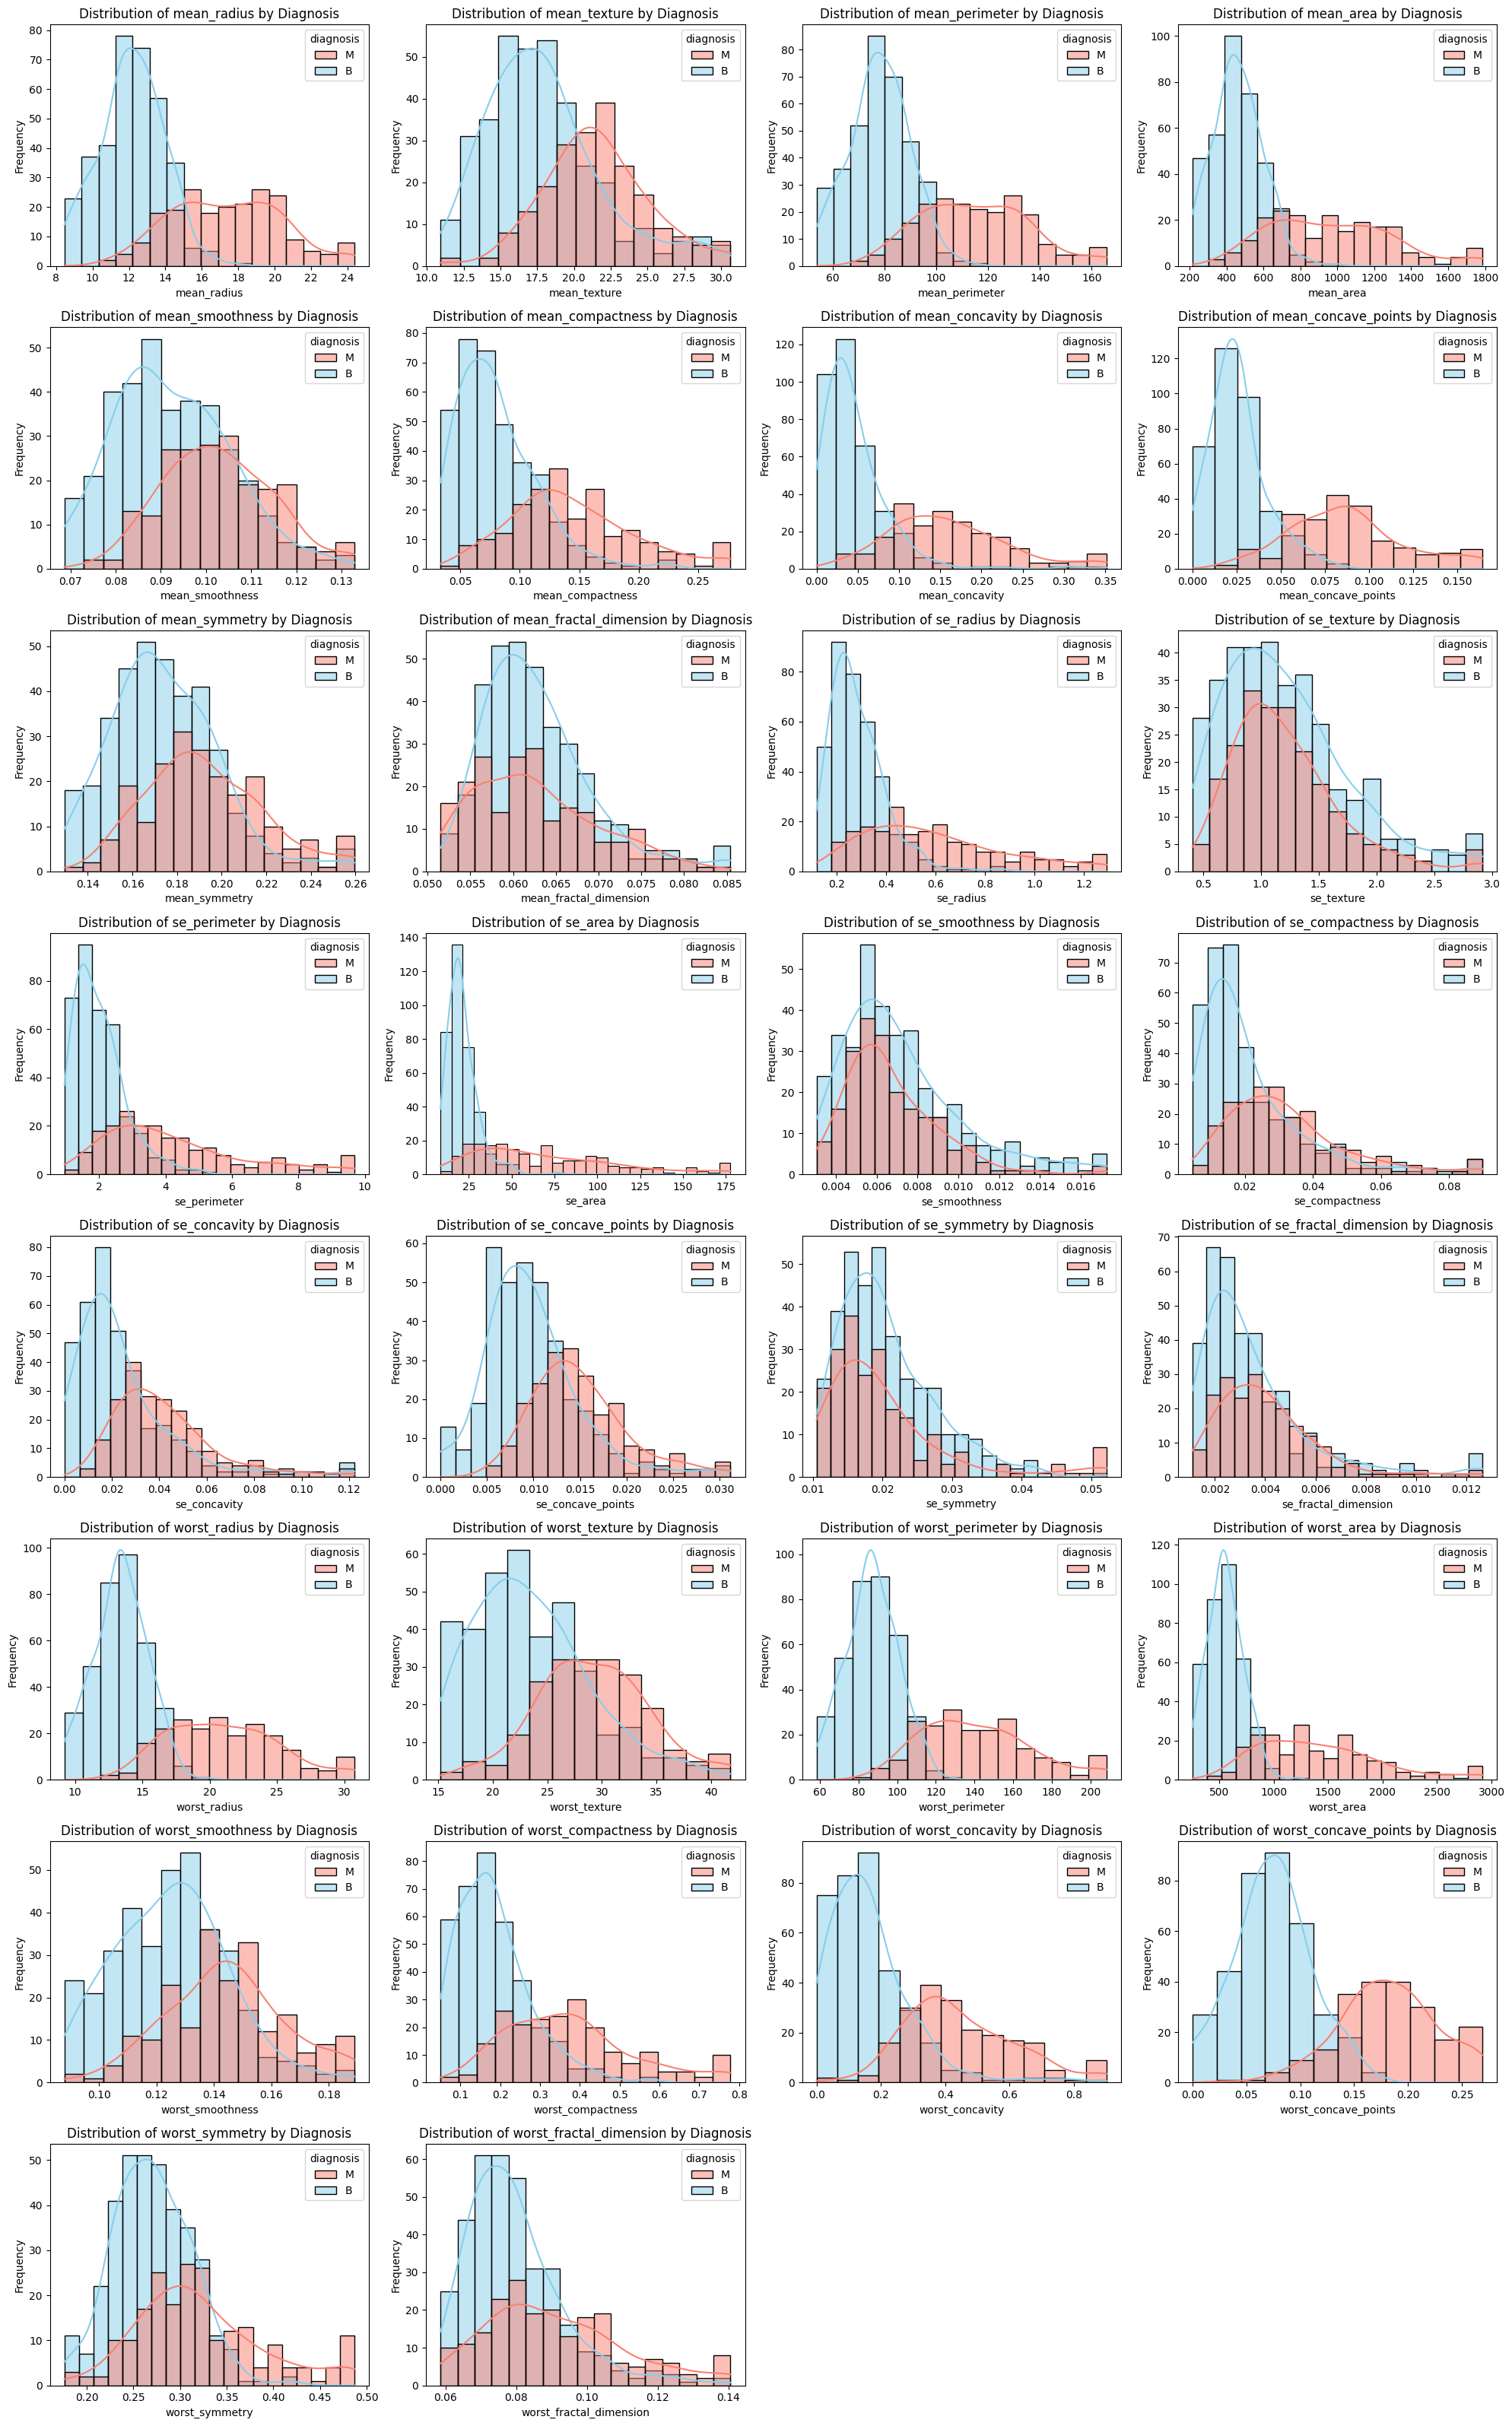

In [15]:
numerical_cols_for_eda = df.select_dtypes(include=np.number).columns.drop(['ID', 'diagnosis_encoded'])

num_features = len(numerical_cols_for_eda)
num_cols_plot = 4
num_rows_plot = (num_features + num_cols_plot - 1) // num_cols_plot

plt.figure(figsize=(num_cols_plot * 5, num_rows_plot * 4))

for i, col in enumerate(numerical_cols_for_eda):
    plt.subplot(num_rows_plot, num_cols_plot, i + 1)
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, palette={'B': 'skyblue', 'M': 'salmon'})
    plt.title(f'Distribution of {col} by Diagnosis')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 2.4 Feature Correlations

Understanding the correlation between features and the target variable, as well as among features themselves, is crucial. A heatmap will visualize these relationships.

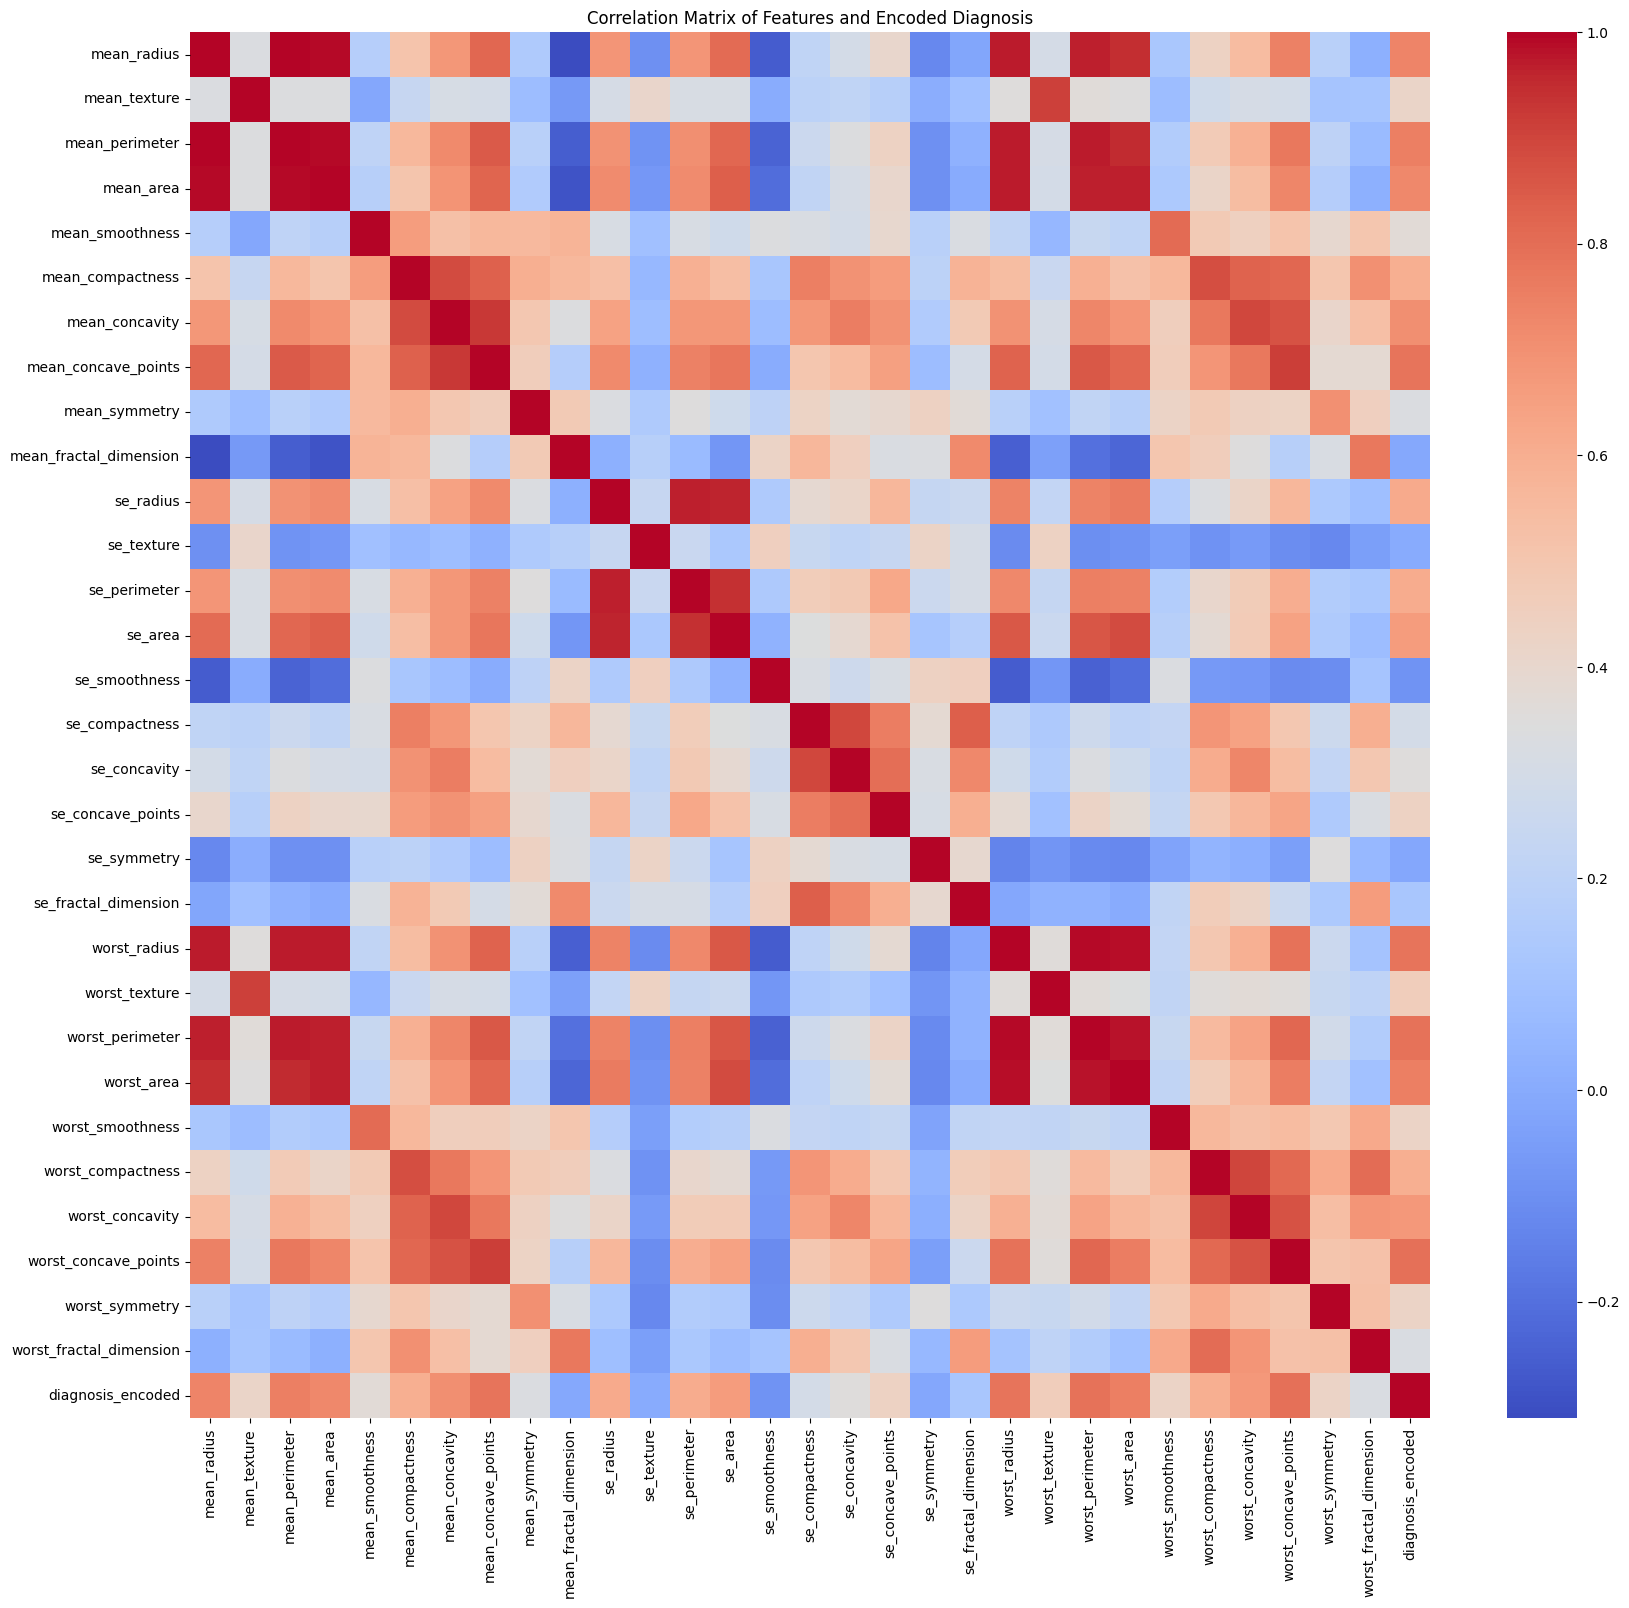


Top 10 features most positively correlated with Malignancy (diagnosis_encoded):


,diagnosis_encoded
worst_concave_points,0.794885
worst_perimeter,0.789946
mean_concave_points,0.784487
worst_radius,0.782806
mean_perimeter,0.750788
worst_area,0.750746
mean_radius,0.738236
mean_area,0.728600
mean_concavity,0.706309
worst_concavity,0.675012



Top 10 features most negatively correlated with Malignancy (diagnosis_encoded):


,diagnosis_encoded
se_smoothness,-0.085943
se_symmetry,-0.016794
mean_fractal_dimension,-0.008498
se_texture,-0.003115
se_fractal_dimension,0.120228
se_compactness,0.298478
worst_fractal_dimension,0.329287
mean_symmetry,0.331318
se_concavity,0.354309
mean_smoothness,0.367419


In [16]:
# Drop the original 'diagnosis' column for correlation, keep 'diagnosis_encoded'
correlation_df = df.drop(columns=['ID', 'diagnosis']).copy()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Encoded Diagnosis')
plt.show()

print("\nTop 10 features most positively correlated with Malignancy (diagnosis_encoded):")
display(correlation_df.corr()['diagnosis_encoded'].sort_values(ascending=False).head(11).drop('diagnosis_encoded'))

print("\nTop 10 features most negatively correlated with Malignancy (diagnosis_encoded):")
display(correlation_df.corr()['diagnosis_encoded'].sort_values(ascending=True).head(10))

### 2.5 Separation Intuition

Let's visualize the separation between benign and malignant cases for some highly correlated features to gain intuition about their discriminative power.

/tmp/ipykernel_6699/2323791760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette={'B': 'skyblue', 'M': 'salmon'})
/tmp/ipykernel_6699/2323791760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette={'B': 'skyblue', 'M': 'salmon'})
/tmp/ipykernel_6699/2323791760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette={'B': 'skyblue', 'M': 'salmon'})
/tmp/ipykernel_6699/2323791760.py:6: FutureWarning: 

Passing `palette` without as

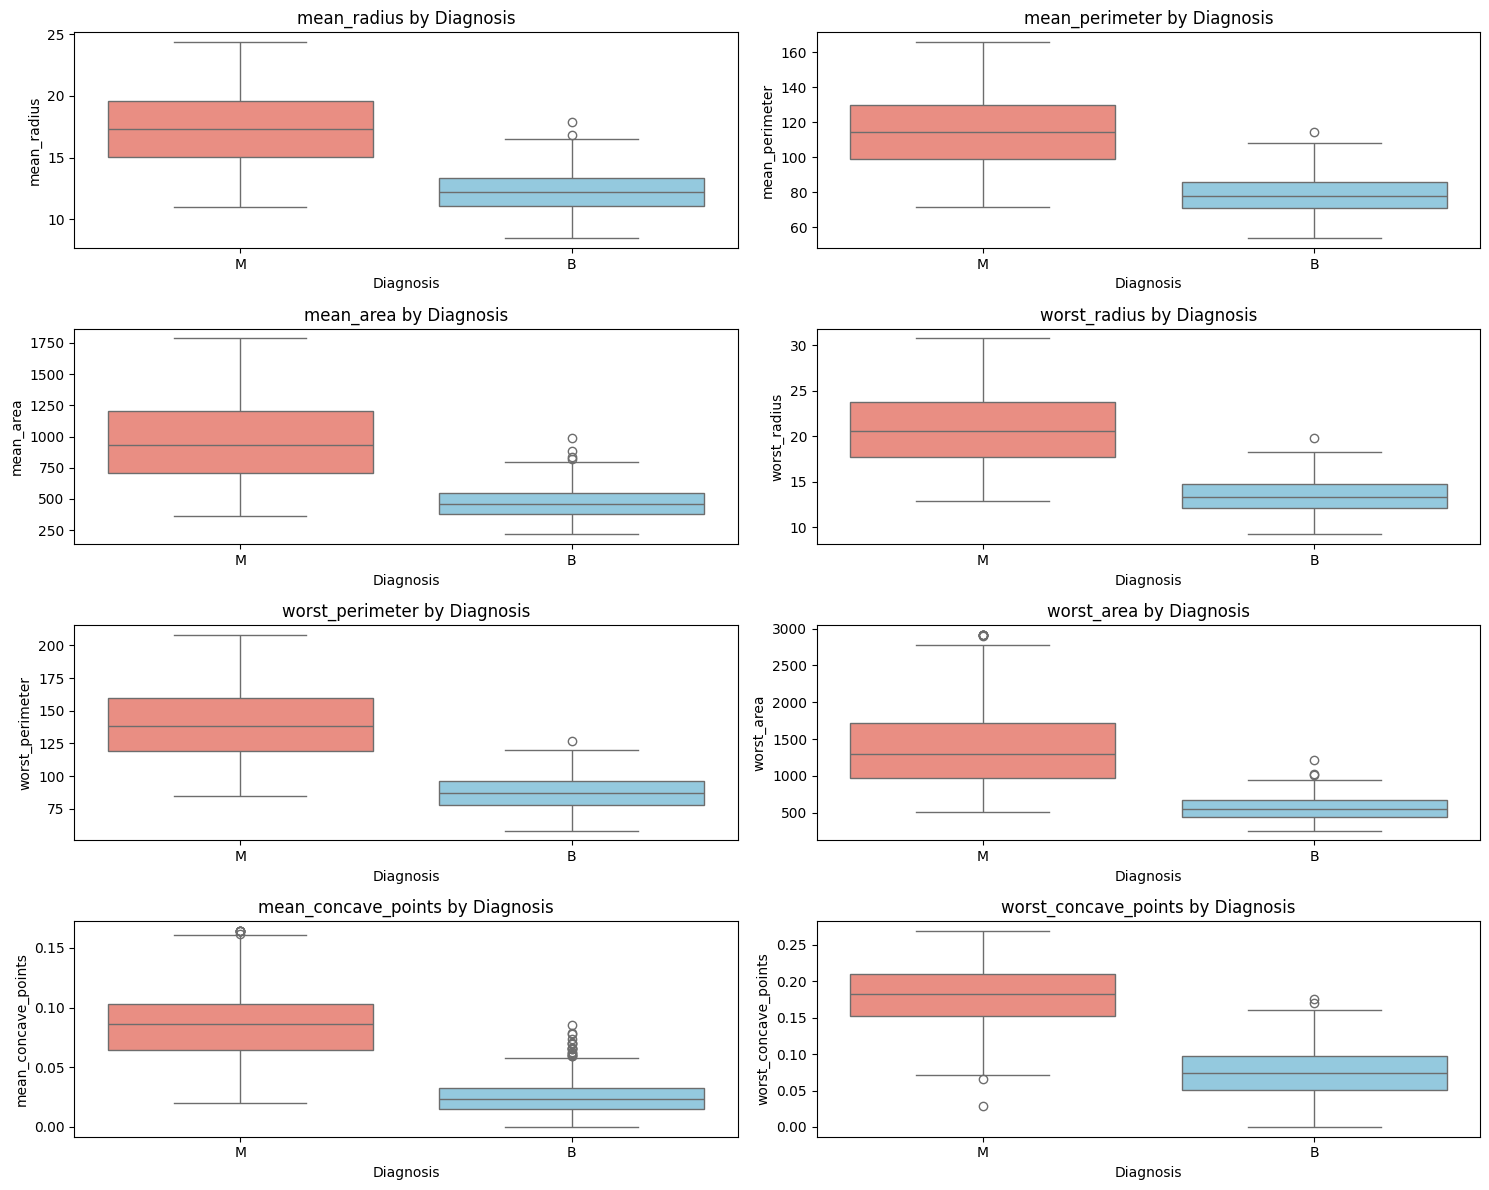

In [17]:
features_for_separation_viz = ['mean_radius', 'mean_perimeter', 'mean_area', 'worst_radius', 'worst_perimeter', 'worst_area', 'mean_concave_points', 'worst_concave_points']

plt.figure(figsize=(15, 12))
for i, col in enumerate(features_for_separation_viz):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x='diagnosis', y=col, data=df, palette={'B': 'skyblue', 'M': 'salmon'})
    plt.title(f'{col} by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### 2.6 EDA Insights Summary

Based on the visualizations and correlation analysis, here are some initial insights:

*   **Class Imbalance:** There is a notable imbalance between benign and malignant cases (~63% Benign, ~37% Malignant). This will be important to consider during model training and evaluation (e.g., stratified splitting, appropriate evaluation metrics).
*   **Strong Predictors:** Features related to `radius`, `perimeter`, `area`, and `concave_points` (especially their 'mean' and 'worst' versions) show very high positive correlation with a malignant diagnosis. This suggests these are strong indicators for tumor classification.
*   **Feature Distributions:** Many features exhibit different distributions between benign and malignant groups, with malignant tumors generally showing higher values for features like radius, perimeter, and area, and also more spread in some cases.
*   **Inter-feature Correlation:** There are strong positive correlations among many of the 'mean', 'se', and 'worst' versions of the same characteristic (e.g., `mean_radius`, `worst_radius`). Also, `radius`, `perimeter`, and `area` measurements are highly correlated, which is expected as they describe related physical dimensions. This multicollinearity might be addressed by some models or through feature selection if needed, but Random Forest is generally robust to it.
*   **Scaling Needs:** While Random Forest is not strictly sensitive to feature scaling, many features operate on different scales. This will be critical for the clustering phase (Phase 9) to ensure all features contribute equally to distance calculations.

These insights will guide the subsequent preprocessing steps and model development.